# S2 · The matrix at the model's default cut

The same clustering and odour enrichment as the main notebook, on predictions alone at
p ≥ 0.50, the default of the released model, with no measurements overlaid. For comparison
with the hybrid matrix only.

## Setup

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")   # library deprecation notices only
%config InlineBackend.figure_format = 'png'

REPO = Path("../../../..").resolve()
sys.path.append(str(REPO / "Downstream_Analysis/scripts"))
sys.path.append(str(REPO / "scripts"))
import activation_code as ac
import activation_figures as af
from plotting_functions import FIGSIZE, custom_plots

plt.rcParams.update(custom_plots())

PROBABILITIES = REPO / "Downstream_Analysis/predictions/aggregated/Reference_Tree_Predictions/reference_median_probability_wide.csv"
M2OR_PAIRS = REPO / "Model_Inputs/Data_Preparation/processed/m2or_pairs_model.csv"
ODOURS = REPO / "Chemicals/processed_data/m2or_inchi_odors_smiles.csv"
PATHWAYS = REPO / "Chemicals/processed_data/ligand_pathways.csv"
FASTA = REPO / "Phylogenetic_Analysis/data/ReferenceTree/PF13853.9606_7955_7740_7764_75743_137246.fa"
CLASSES = REPO / "Phylogenetic_Analysis/data/HumanTree/human433_OR_classes.csv"
TREE = REPO / "Phylogenetic_Analysis/data/HumanTree/human433_MFP_reorder.tree"

FIGURES = Path("Figures")
TABLES = Path("Tables")
MAIN_TABLES = Path("../Tables")     # written by ../figure2_activation_code.ipynb
FIGURES.mkdir(exist_ok=True)
TABLES.mkdir(exist_ok=True)
NAME = "hybrid_density"

In [2]:
data = ac.load_activation_data(PROBABILITIES, M2OR_PAIRS, FASTA)
smiles_by_odorant, tags_by_odorant = ac.odour_tags(M2OR_PAIRS, ODOURS, data.odorant_ids)
class_of = ac.receptor_classes(CLASSES)
print(f"density {data.fill.density:.4%}   cut {data.fill.cut:.4f} (an output of the fill)")

tree_order = ac.tree_tip_order(TREE)
baseline = (data.scores >= 0.50).astype(int)
print(f"densities  hybrid {data.hybrid.mean():.4f}   baseline {baseline.mean():.4f}")

density 2.7453%   cut 0.8917 (an output of the fill)
densities  hybrid 0.0275   baseline 0.1356


In [3]:
clustered_ids, clustered_matrix, labels = ac.cluster_odorants(baseline, data.odorant_ids)
enrichment = ac.tag_enrichment(clustered_ids, labels, tags_by_odorant)
significant = ac.significant_enrichment(enrichment)
info, display_order = ac.name_clusters(enrichment, labels)
print(f"baseline  sizes {sorted([info[c]['size'] for c in display_order], reverse=True)}  #sig {len(significant)}")
enrichment.sort_values(["cluster", "fdr"]).to_csv(TABLES / "enrichment_baseline.csv", index=False)

baseline  sizes [159, 149, 145, 142, 89, 67]  #sig 38


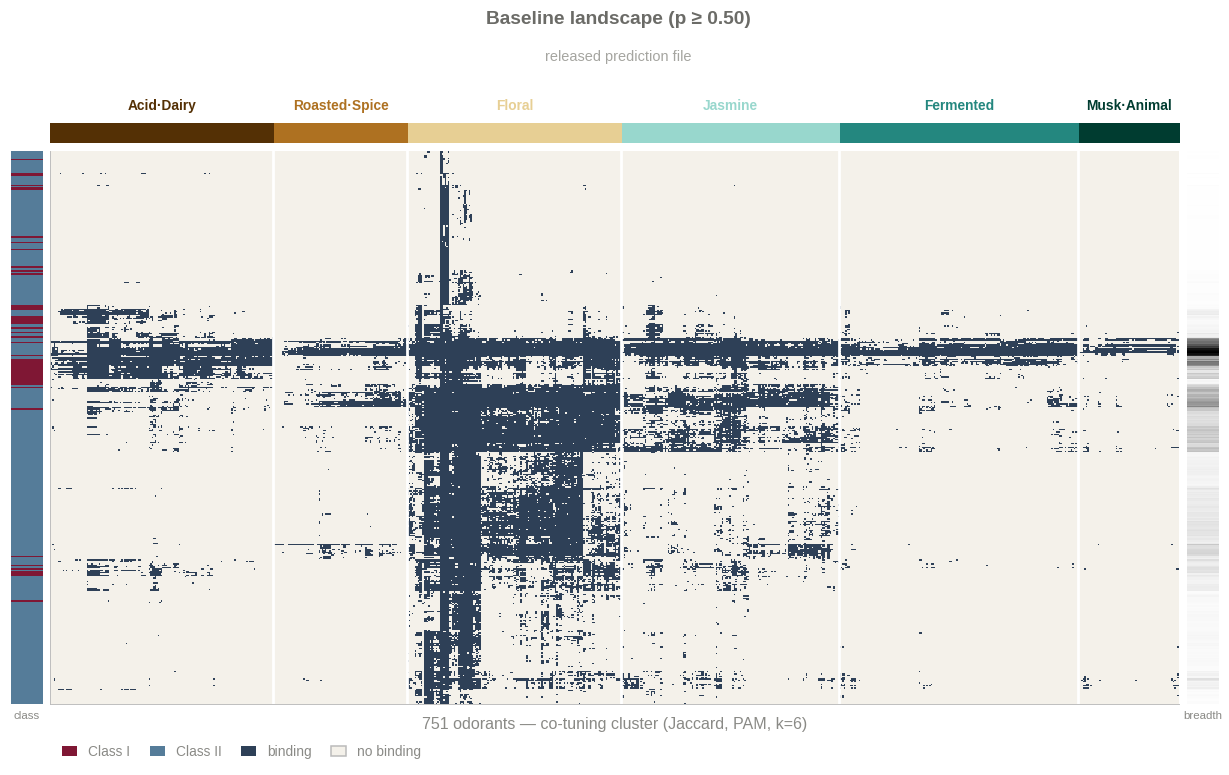

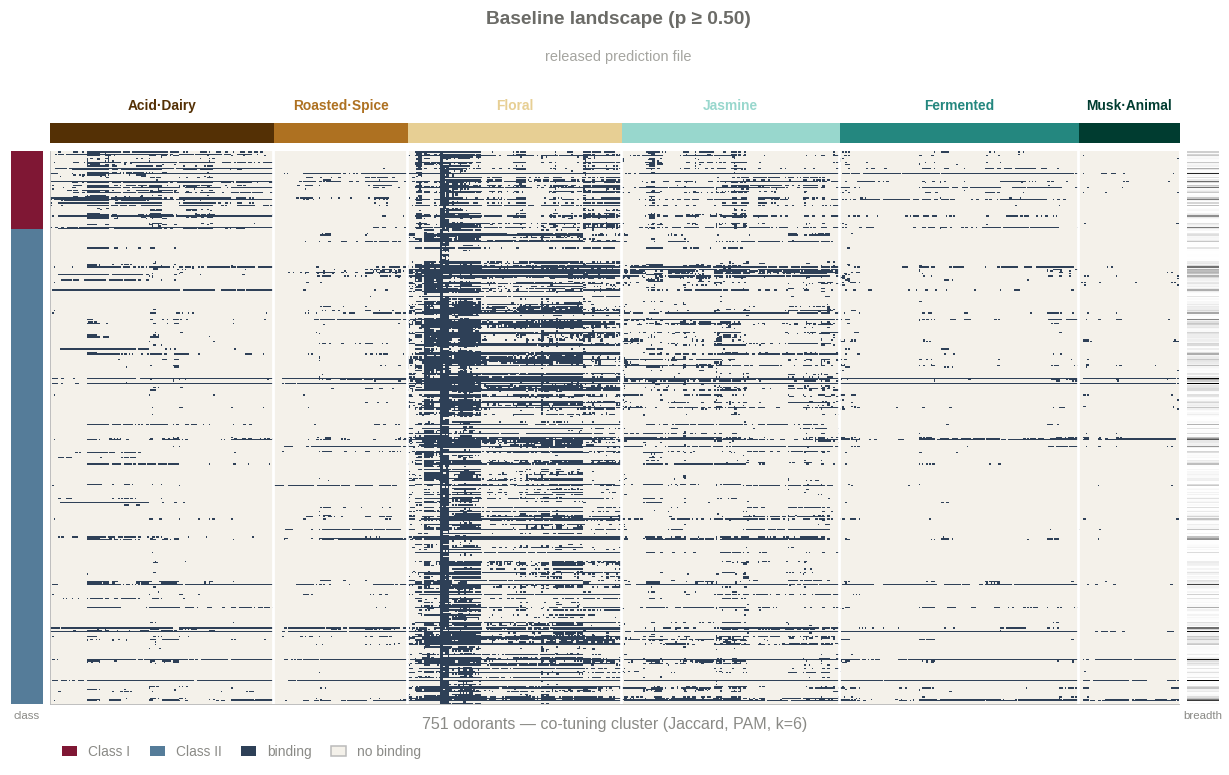

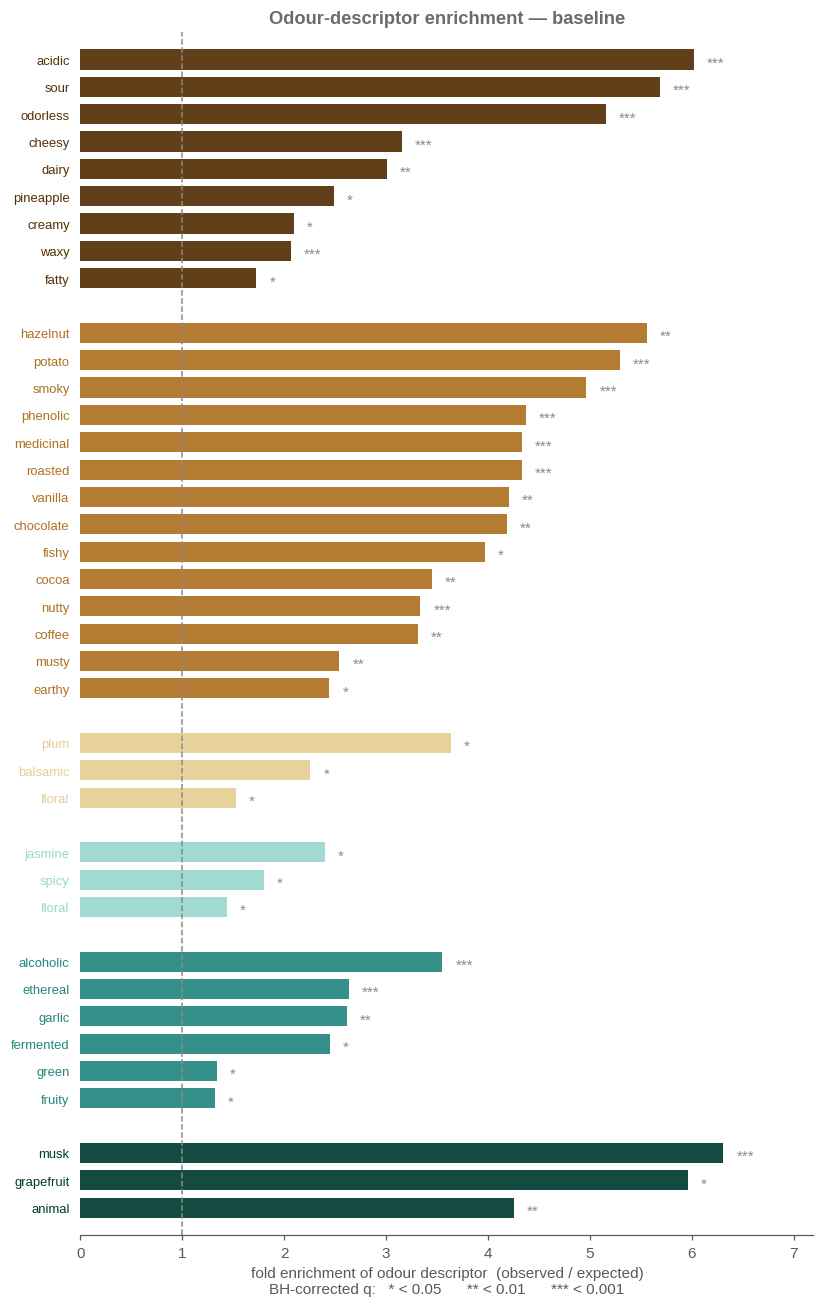

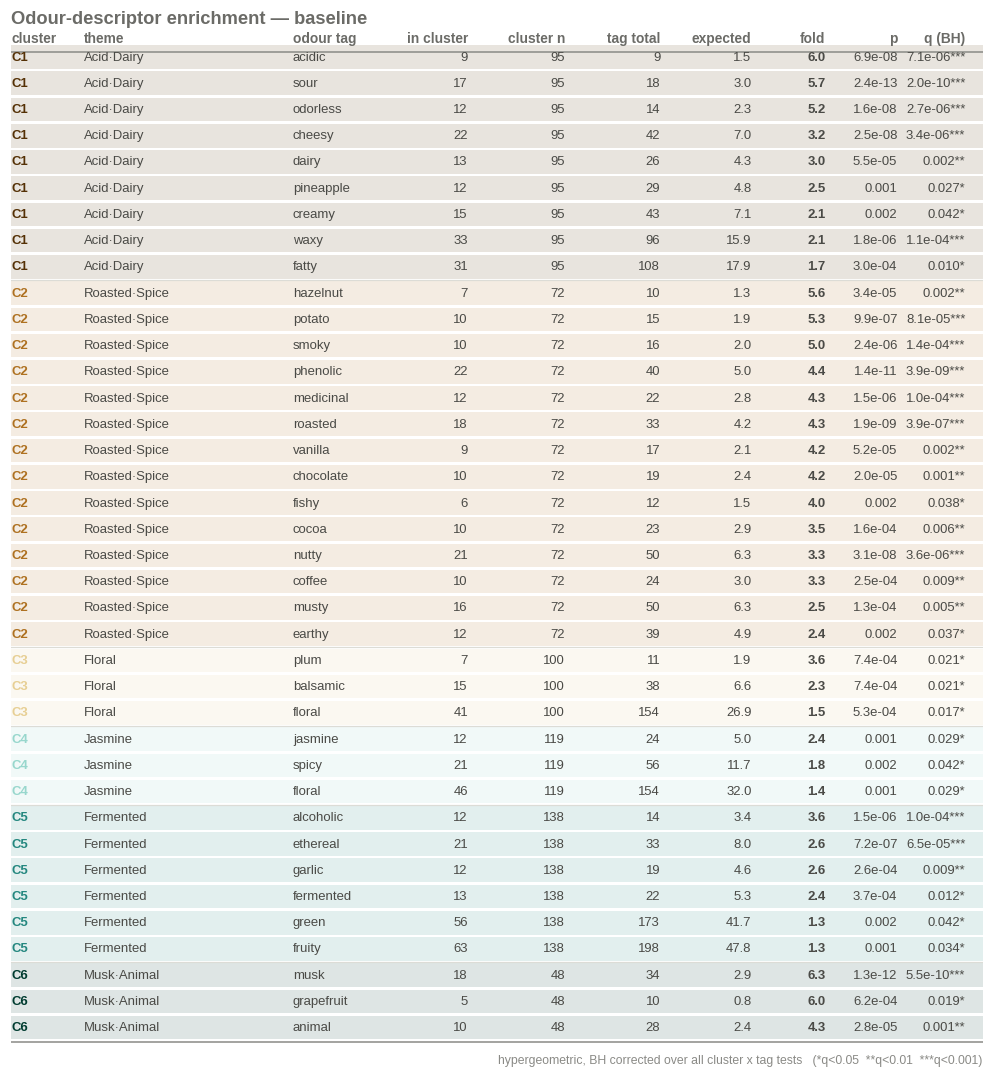

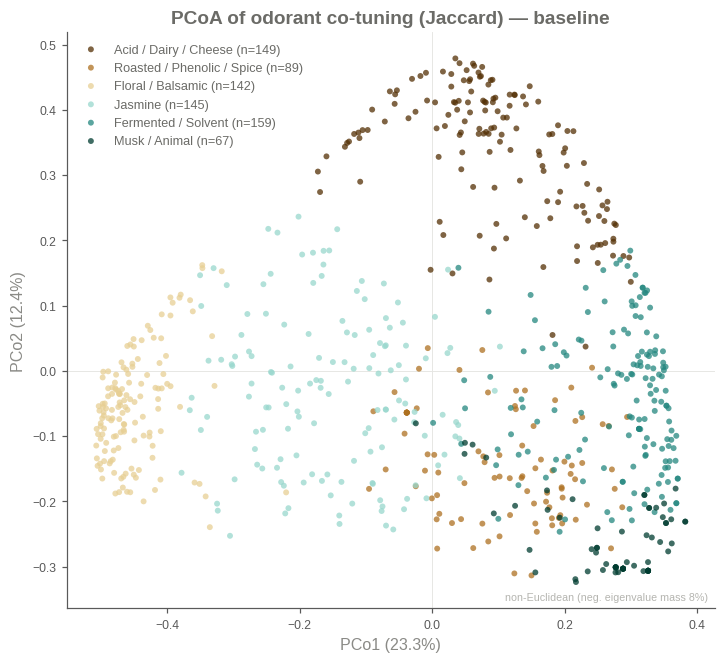

In [4]:
title, subtitle = "Baseline landscape (p ≥ 0.50)", "released prediction file"
af.activation_heatmap(clustered_ids, clustered_matrix, labels, info, display_order, data.receptor_ids, class_of,
                      title, subtitle, FIGURES / "heatmap_baseline.svg", row_order="cotuning", show=True)
af.activation_heatmap(clustered_ids, clustered_matrix, labels, info, display_order, data.receptor_ids, class_of,
                      title, subtitle, FIGURES / "heatmap_baseline_tree_order.svg", row_order="tree", show=True,
                      tree_order=tree_order)
af.enrichment_bars(significant, info, display_order, "Odour-descriptor enrichment — baseline",
                   FIGURES / "enrichbar_baseline.svg", show=True)
enrichment_rows = af.enrichment_table_rows(significant, info, display_order)
enrichment_rows.drop(columns="color").to_csv(TABLES / "enrichment_table_baseline.csv", index=False)
af.enrichment_table_figure(enrichment_rows, "Odour-descriptor enrichment — baseline",
                           FIGURES / "enrichment_table_baseline.svg", show=True)
af.pcoa_figure(clustered_matrix, labels, info, display_order, "PCoA of odorant co-tuning (Jaccard) — baseline",
               FIGURES / "pcoa_baseline.svg", show=True)